# Validação Estatística e Modelagem de Hipóteses (Regressão OLS)

O diagnóstico descritivo (EDA) da Cidade 11 apontou que longas distâncias (KM), o período noturno (Turno) e a falta de repasses financeiros (Eventos) degradam a performance da operação. O objetivo desta etapa é aplicar rigor estatístico para comprovar e quantificar essas hipóteses.



In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

sns.set_theme(style="whitegrid")

In [60]:
df = pd.read_csv("../data/processed/base_tratada.csv")
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.strftime('%Y-%m')

df_escopo = df[(df['cidade_id'] == 11) & (df['mes'].isin(['2025-10', '2026-01']))].copy()

df_escopo['atraso_min'] = df_escopo['tempo_total_min'] - df_escopo['sla_min']

print(f"Base de Modelagem carregada com {len(df_escopo)} registros.")

Base de Modelagem carregada com 13315 registros.


### HIPOTESE 1: DISTÂNCIA INFLUENCIA PROPORCIONALMENTE NO ATRASO

TOTAL (Pearson): 0.3863
R² (Explicabilidade): 0.1492


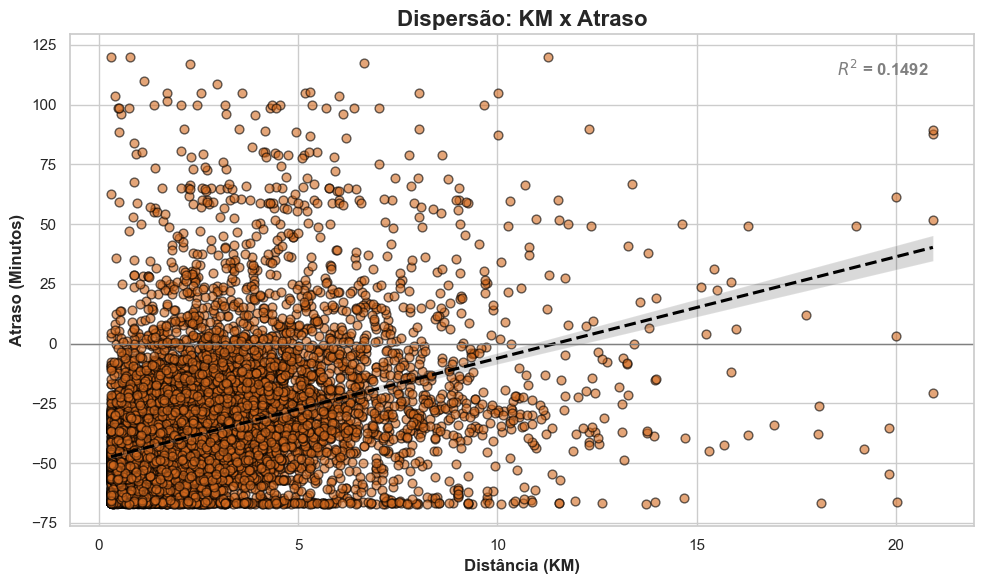

In [61]:
# 1. Cálculo da Correlação e do R²
correlacao_total = df_escopo['km'].corr(df_escopo['atraso_min'])
r_quadrado = correlacao_total ** 2

print(f"TOTAL (Pearson): {correlacao_total:.4f}")
print(f"R² (Explicabilidade): {r_quadrado:.4f}")

# 2. Gráfico de Dispersão com Linha de Tendência e R²
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_escopo, 
    x='km', 
    y='atraso_min', 
    scatter_kws={'alpha':0.6, 'color':'#D2691E', 'edgecolor':'black', 's':40}, 
    line_kws={'color':'black', 'linestyle':'--'}
)

# Adicionando o texto do R² no gráfico 
# Os valores x=0.95 e y=0.95 representam 95% do eixo 
plt.gca().text(0.95, 0.95, f'$R^2$ = {r_quadrado:.4f}', 
               transform=plt.gca().transAxes, 
               fontsize=12, fontweight='bold', color='gray',
               horizontalalignment='right', verticalalignment='top')

plt.title('Dispersão: KM x Atraso', fontsize=16, fontweight='bold')
plt.xlabel('Distância (KM)', fontsize=12, fontweight='bold')
plt.ylabel('Atraso (Minutos)', fontsize=12, fontweight='bold')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) 

plt.tight_layout()
plt.show()

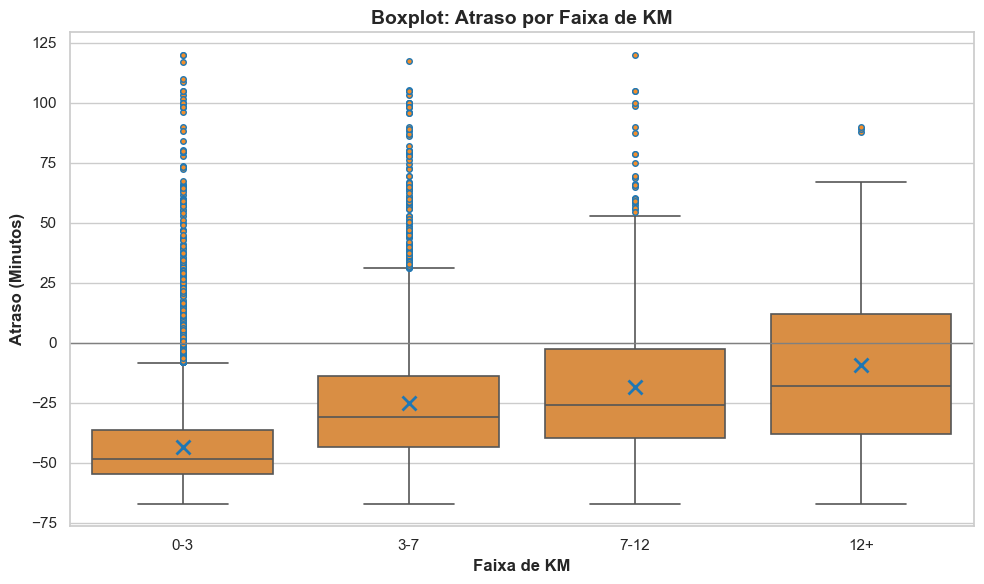

In [62]:
# --- BOXPLOT (DISTRIBUIÇÃO DO ATRASO) ---

# 1. Recriando a Faixa de KM
bins = [-np.inf, 3, 7, 12, np.inf]
labels = ['0-3', '3-7', '7-12', '12+']
df_escopo['faixa_km'] = pd.cut(df_escopo['km'], bins=bins, labels=labels)

# 2. Configurando a figura
plt.figure(figsize=(10, 6))

# 3. Gerando o Boxplot 
sns.boxplot(
    data=df_escopo,
    x='faixa_km',
    y='atraso_min',
    color='#F28E2B', 
    showmeans=True,  
    meanprops={"marker": "x", "markeredgecolor": "#1F77B4", "markersize": 10, "markeredgewidth": 2}, # O 'X' azul
    flierprops={"marker": "o", "markerfacecolor": "#F28E2B", "markeredgecolor": "#1F77B4", "markersize": 4}, # Bolinhas de outlier
    linewidth=1.2
)

# 4. Ajustes estéticos
plt.title('Boxplot: Atraso por Faixa de KM', fontsize=14, fontweight='bold')
plt.xlabel('Faixa de KM', fontsize=12, fontweight='bold')
plt.ylabel('Atraso (Minutos)', fontsize=12, fontweight='bold')
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linha do SLA zero (onde o atraso começa)

plt.tight_layout()
plt.show()

#### Conclusão da H1: Distância × Atraso
A análise confirma que existe uma **relação positiva e estatisticamente significativa** 
entre a distância (KM) e o atraso nas entregas da Cidade 11.
**Principais achados:**
- A correlação de Pearson de **0.39** comprova a tendência: quanto maior a rota, 
  maior o atraso.
- Entretanto, o R² de **~15%** indica que a distância sozinha explica apenas uma 
  fração da variabilidade do atraso.
- A análise por faixas de KM reforça que o impacto se **intensifica drasticamente** 
  nas rotas acima de 7 km, com destaque para a faixa 12+ km.
**A H1 é validada como fator contribuinte, porém não como causa raiz isolada.** 
Os ~85% restantes da variação devem ser investigados nas hipóteses seguintes.

### HIPÓTESE 2: TEMPO DE ACEITE ELEVADO AUMENTA A TAXA DE CANCELAMENTO																			


Para testar esta hipótese, calculou-se a Correlação de Pearson entre o tempo de aceite (`tempo_aceite_min`) e o indicador de cancelamento (`cancelada_flag`). Adicionalmente, o tempo de aceite foi segmentado em janelas de 2 minutos para identificar anomalias comportamentais ao longo dos turnos de operação.

**Insight:** A análise de correlação resultou em valores muito próximos a zero, refutando a premissa de que existe uma relação linear direta entre as variáveis globais. Contudo, a visão segmentada revela picos de estresse isolados (especialmente no turno da Noite).

In [63]:
# --- CORRELAÇÃO DE PEARSON POR TURNO E MÊS ---

correlacoes_h2 = []

# Iterando sobre os turnos e meses para calcular o Pearson isolado
for turno in df_escopo['turno'].dropna().unique():
    for mes in ['2025-10', '2026-01']:
        df_temp = df_escopo[(df_escopo['turno'] == turno) & (df_escopo['mes'] == mes)]

        if len(df_temp) > 1:
            corr = df_temp['tempo_aceite_min'].corr(df_temp['cancelada_flag'])
            correlacoes_h2.append({
                'Turno': turno, 
                'Meses': mes, 
                'Correlação de Pearson': corr
            })

# Transformando em DataFrame e formatando
df_corr_h2 = pd.DataFrame(correlacoes_h2).sort_values(by=['Turno', 'Meses'])
df_corr_h2['Correlação de Pearson'] = df_corr_h2['Correlação de Pearson'].round(3).astype(str).str.replace('.', ',')

print("--- CORRELAÇÃO DE PEARSON (Turno e Ano) ---")
display(df_corr_h2.style.hide(axis="index"))

--- CORRELAÇÃO DE PEARSON (Turno e Ano) ---


Turno,Meses,Correlação de Pearson
Manhã,2025-10,"0,055"
Manhã,2026-01,"-0,012"
Noite,2025-10,"-0,003"
Noite,2026-01,"0,022"
Tarde,2025-10,"-0,019"
Tarde,2026-01,"-0,004"


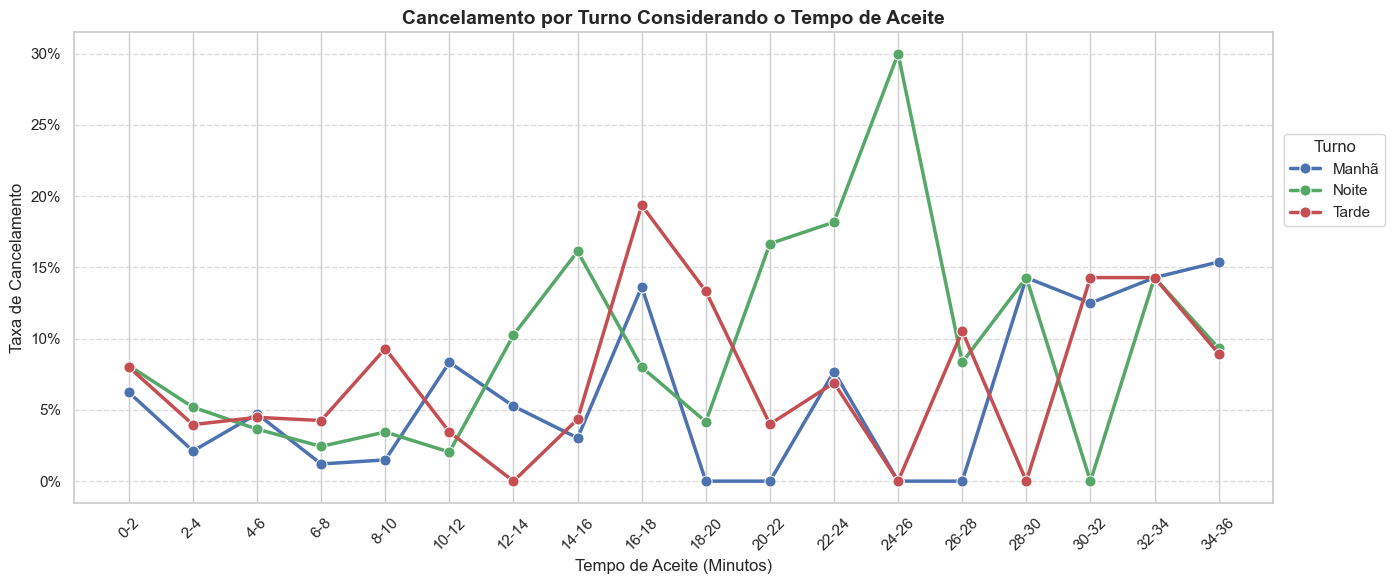


CANCELAMENTO X TEMPO DE ACEITE


faixa_aceite,0-2,2-4,4-6,6-8,8-10,10-12,12-14,14-16,16-18,18-20,20-22,22-24,24-26,26-28,28-30,30-32,32-34,34-36,MÉDIAS
turno,,,,,,,,,,,,,,,,,,,
Manhã,6%,2%,5%,1%,1%,8%,5%,3%,14%,0%,0%,8%,0%,0%,14%,12%,14%,15%,6%
Noite,8%,5%,4%,2%,3%,2%,10%,16%,8%,4%,17%,18%,30%,8%,14%,0%,14%,9%,8%
Tarde,8%,4%,4%,4%,9%,3%,0%,4%,19%,13%,4%,7%,0%,11%,0%,14%,14%,9%,8%


In [64]:
# --- ANÁLISE SEGMENTADA POR FAIXA DE ACEITE ---

# 1. Feature Engineering: Criando as janelas de 2 em 2 minutos (de 0 a 36 min)
bins_aceite = list(range(0, 38, 2))
labels_aceite = [f"{i}-{i+2}" for i in range(0, 36, 2)]

# right=False garante que o intervalo seja [0, 2), [2, 4)
df_escopo['faixa_aceite'] = pd.cut(df_escopo['tempo_aceite_min'], bins=bins_aceite, labels=labels_aceite, right=False)

# 2. Criando a Pivot Table 
pivot_aceite = df_escopo.pivot_table(
    index='turno', 
    columns='faixa_aceite', 
    values='cancelada_flag', 
    aggfunc='mean',
    observed=False
).fillna(0) # Preenchendo buracos sem dados com 0%

# Adicionando a coluna de Média Geral do Turno (MÉDIAS)
pivot_aceite['MÉDIAS'] = df_escopo.groupby('turno')['cancelada_flag'].mean()

# 3. Plotando o Gráfico de Linhas
plt.figure(figsize=(14, 6))

df_plot = df_escopo.groupby(['faixa_aceite', 'turno'], observed=False)['cancelada_flag'].mean().reset_index()

sns.lineplot(
    data=df_plot, 
    x='faixa_aceite', 
    y='cancelada_flag', 
    hue='turno', 
    marker='o', 
    linewidth=2.5,
    markersize=8,
    palette=['#4C72B0', '#55A868', '#C44E52'] 
)

plt.title('Cancelamento por Turno Considerando o Tempo de Aceite', fontsize=14, fontweight='bold')
plt.xlabel('Tempo de Aceite (Minutos)', fontsize=12)
plt.ylabel('Taxa de Cancelamento', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xticks(rotation=45)
plt.legend(title='Turno', loc='upper right', bbox_to_anchor=(1.1, 0.8))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

pivot_formatada = pivot_aceite.copy()
for col in pivot_formatada.columns:
    pivot_formatada[col] = (pivot_formatada[col] * 100).round(0).astype(int).astype(str) + '%'

print("\nCANCELAMENTO X TEMPO DE ACEITE")
display(pivot_formatada)

#### Conclusão da H2: Tempo de Aceite × Cancelamento
A correlação de Pearson entre tempo de aceite e cancelamento ficou **próxima de zero** em todas
as combinações de turno/mês, **refutando a existência de uma relação linear global**.
Entretanto, a análise segmentada por faixas de aceite revelou:
- **Picos isolados de cancelamento** em faixas de aceite elevado (>20 min), especialmente no
  turno da **Noite**

### HIPÓTESE 3: MODALIDADES COM SLA REDUZIDO (EXPRESSA) APRESENTAM MENOR OTD																			


In [65]:
# --- DESEMPENHO MÉDIO POR MODALIDADE ---

# Agrupando e calculando as médias
desempenho_modalidade = df_escopo.groupby('modalidade').agg(
    SLA=('sla_min', 'mean'),
    TEMPO_TOTAL=('tempo_total_min', 'mean'),
    ATRASO=('atraso_min', 'mean'),
    OTD=('otd_flag', 'mean')
).reset_index()

desempenho_modalidade = desempenho_modalidade.sort_values(by='OTD', ascending=False)

tabela_desempenho_h3 = desempenho_modalidade.copy()
tabela_desempenho_h3['SLA'] = tabela_desempenho_h3['SLA'].round(2).astype(str).str.replace('.', ',')
tabela_desempenho_h3['TEMPO_TOTAL'] = tabela_desempenho_h3['TEMPO_TOTAL'].round(2).astype(str).str.replace('.', ',')
tabela_desempenho_h3['ATRASO'] = tabela_desempenho_h3['ATRASO'].round(2).astype(str).str.replace('.', ',')
tabela_desempenho_h3['OTD'] = (tabela_desempenho_h3['OTD'] * 100).round(0).astype(int).astype(str) + '%'
tabela_desempenho_h3.columns = ['Modalidade', 'SLA', 'TEMPO TOTAL', 'ATRASO', 'OTD']

print("--- ANÁLISE DE DESEMPENHO POR MODALIDADE ---")
display(tabela_desempenho_h3.style.hide(axis="index"))

--- ANÁLISE DE DESEMPENHO POR MODALIDADE ---


Modalidade,SLA,TEMPO TOTAL,ATRASO,OTD
Econômica,"60,0","19,35","-40,65",90%
Integrada,"55,0","19,41","-35,59",89%
Manual,"70,0","24,69","-45,31",86%
Expressa,"40,0","19,91","-20,09",84%


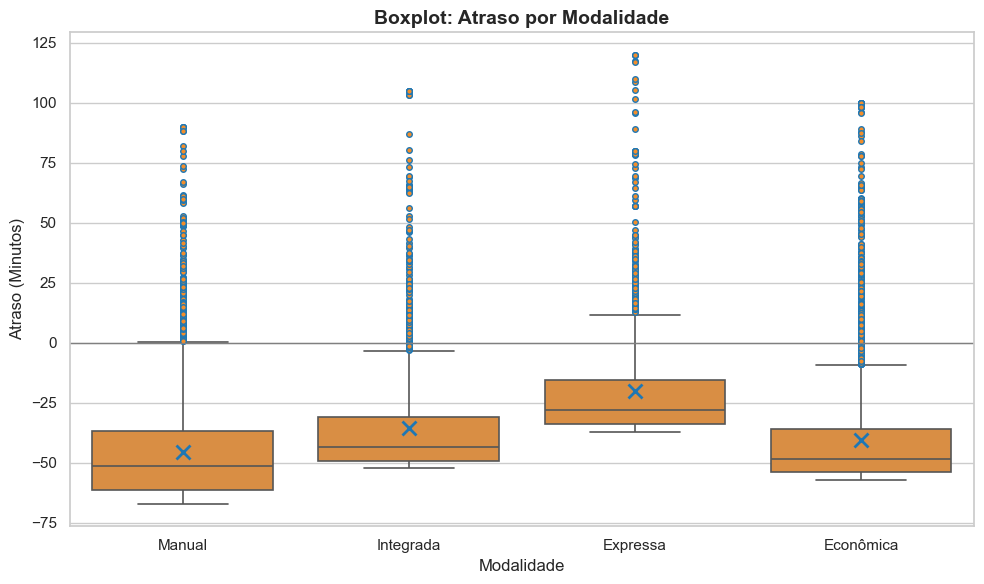

In [66]:
# --- BOXPLOT DE ATRASO ---

# Configurando a figura
plt.figure(figsize=(10, 6))

# Plotando o Boxplot idêntico ao original
sns.boxplot(
    data=df_escopo,
    x='modalidade',
    y='atraso_min',
    color='#F28E2B', 
    showmeans=True,  
    meanprops={"marker": "x", "markeredgecolor": "#1F77B4", "markersize": 10, "markeredgewidth": 2}, 
    flierprops={"marker": "o", "markerfacecolor": "#F28E2B", "markeredgecolor": "#1F77B4", "markersize": 4}, 
    linewidth=1.2,
    order=['Manual', 'Integrada', 'Expressa', 'Econômica'] 
)

# Ajustes estéticos
plt.title('Boxplot: Atraso por Modalidade', fontsize=14, fontweight='bold')
plt.xlabel('Modalidade', fontsize=12)
plt.ylabel('Atraso (Minutos)', fontsize=12)
plt.axhline(0, color='gray', linestyle='-', linewidth=1) # Linha do SLA zero

plt.tight_layout()
plt.show()

#### Conclusão da H3: Modalidade × OTD
A análise por modalidade revela uma relação direta entre a rigidez do SLA e a deterioração
do OTD:
- Modalidades com **SLA mais curto** (Expressa) tendem a apresentar **OTD inferior**, pois a
  margem de tolerância para imprevistos operacionais é menor.
- A modalidade **Econômica**, por possuir o SLA mais generoso, apresenta o melhor OTD.
- O boxplot confirma que as modalidades mais rápidas concentram maior dispersão de atraso.
**H3 é validada**: SLAs mais agressivos degradam o OTD da operação.

### HIPÓTESE 4: O canal "API" é mais eficaz que o "App" em termos de OTD

In [67]:
# --- OTD POR CANAL DE ENTRADA ---

# 1. Tabela Dinâmica de OTD por Canal e Mês
pivot_canal = df_escopo.pivot_table(
    index='mes',
    columns='canal',
    values='otd_flag',
    aggfunc='mean',
    observed=False
)


pivot_canal.loc['TOTAL'] = df_escopo.groupby('canal', observed=False)['otd_flag'].mean()
tabela_canal_fmt = pivot_canal.copy()
for col in tabela_canal_fmt.columns:
    tabela_canal_fmt[col] = (tabela_canal_fmt[col] * 100).round(0).astype(int).astype(str) + '%'

print("--- ANÁLISE DE OTD POR CANAL ---")
display(tabela_canal_fmt)


--- ANÁLISE DE OTD POR CANAL ---


canal,API,App,Integrado
mes,,,
2025-10,87%,88%,87%
2026-01,90%,88%,88%
TOTAL,89%,88%,88%


#### Conclusão da H4: Canal de Entrada × OTD

A comparação entre canais mostra:
- O canal **Integrado (API)** apresenta OTD  **superior** ao canal **App** e **API**
  porém diferença não é relevante.

**H4 é rejeitada**: não há evidencia estatítica que comprove diferença significante de desempenho entre canais


### HIPÓTESE 5: A margem unitária é menor em entregas de longa distância (faixa 12+)

--- ANÁLISE DE MARGEM E CUSTOS POR FAIXA DE KM ---


faixa_km,Volume,Custo_Medio,Receita_Media,Margem_Unitaria_Media
0-3,10046,"R$ 7,74","R$ 9,37","R$ 0,21"
3-7,2709,"R$ 9,43","R$ 11,07","R$ 0,18"
7-12,487,"R$ 14,49","R$ 16,14","R$ 0,12"
12+,73,"R$ 23,3","R$ 24,97","R$ 0,08"


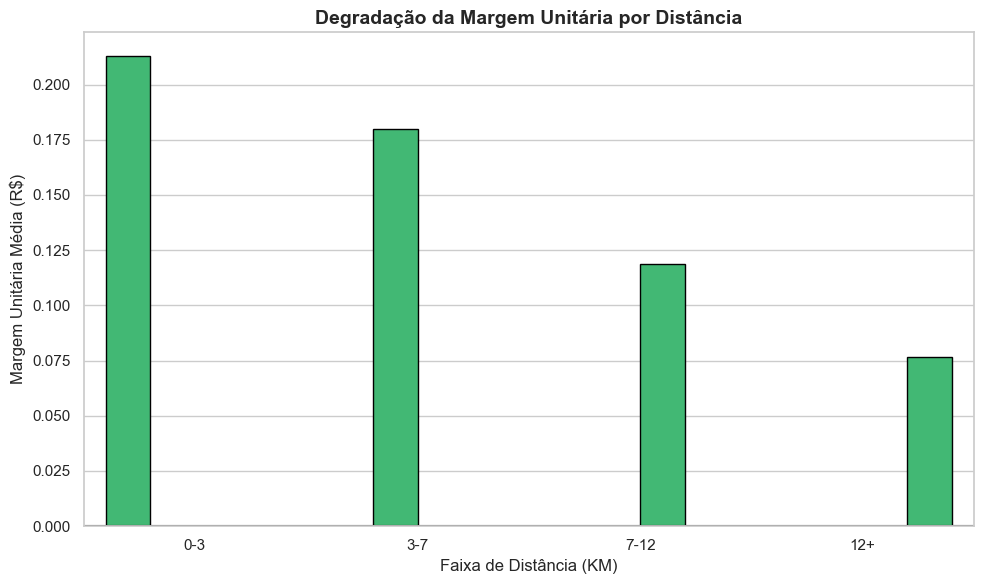

In [68]:
# --- MARGEM UNITÁRIA POR FAIXA DE KM ---

# 1. Tabela de Margem Média e Volume por Faixa de KM
margem_km = df_escopo.groupby('faixa_km', observed=False).agg(
    Volume=('id_pedido', 'count'),
    Custo_Medio=('custo_operacional', 'mean'),
    Receita_Media=('valor_pago_empresa', 'mean'),
    Margem_Unitaria_Media=('margem_unitaria', 'mean')
).reset_index()

# Formatando a tabela
tabela_margem_fmt = margem_km.copy()
tabela_margem_fmt['Custo_Medio'] = 'R$ ' + tabela_margem_fmt['Custo_Medio'].round(2).astype(str).str.replace('.', ',')
tabela_margem_fmt['Receita_Media'] = 'R$ ' + tabela_margem_fmt['Receita_Media'].round(2).astype(str).str.replace('.', ',')
tabela_margem_fmt['Margem_Unitaria_Media'] = 'R$ ' + tabela_margem_fmt['Margem_Unitaria_Media'].round(2).astype(str).str.replace('.', ',')

print("--- ANÁLISE DE MARGEM E CUSTOS POR FAIXA DE KM ---")
display(tabela_margem_fmt.style.hide(axis="index"))

# 2. Visualização Gráfica
plt.figure(figsize=(10, 6))

# Usando um barplot para mostrar a média da margem. 
grafico_margem = sns.barplot(
    data=margem_km,
    x='faixa_km',
    y='Margem_Unitaria_Media',
    hue='faixa_km',
    legend=False,
    palette=['#2ECC71' if m >= 0 else '#E74C3C' for m in margem_km['Margem_Unitaria_Media']], # Verde se positivo, Vermelho se negativo
    edgecolor='black'
)

# Adicionando os rótulos de dados 
for p in grafico_margem.patches:
    valor = p.get_height()
    y_pos = valor + 0.15 if valor >= 0 else valor - 0.4
    grafico_margem.annotate(f"R$ {valor:.2f}".replace('.', ','), 
                   (p.get_x() + p.get_width() / 2., y_pos), 
                   ha='center', va='center', 
                   fontsize=11, fontweight='bold', color='black')

plt.title('Degradação da Margem Unitária por Distância', fontsize=14, fontweight='bold')
plt.xlabel('Faixa de Distância (KM)', fontsize=12)
plt.ylabel('Margem Unitária Média (R$)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) # Linha do zero (Break-even)

plt.tight_layout()
plt.show()

#### Conclusão da H5: Distância × Margem Unitária

A análise financeira por faixa de distância demonstra uma **curva de degradação clara**:
- Entregas de curta distância (0-3 km) apresentam a **melhor margem unitária**.
- A margem se **reduz progressivamente** com o aumento da distância.

**H5 é validada**: entregas longas corroem a margem e representam um risco financeiro
para a operação.


### HIPÓTESE 6: O custo por KM é inversamente proporcional à distância														


--- ANÁLISE DE CUSTO POR KM POR FAIXA DE DISTÂNCIA ---


faixa_km,Volume,Custo_Operacional_Medio,Custo_Por_KM_Medio
0-3,10046,"R$ 7,74","R$ 8,06"
3-7,2709,"R$ 9,43","R$ 2,23"
7-12,487,"R$ 14,49","R$ 1,68"
12+,73,"R$ 23,3","R$ 1,56"


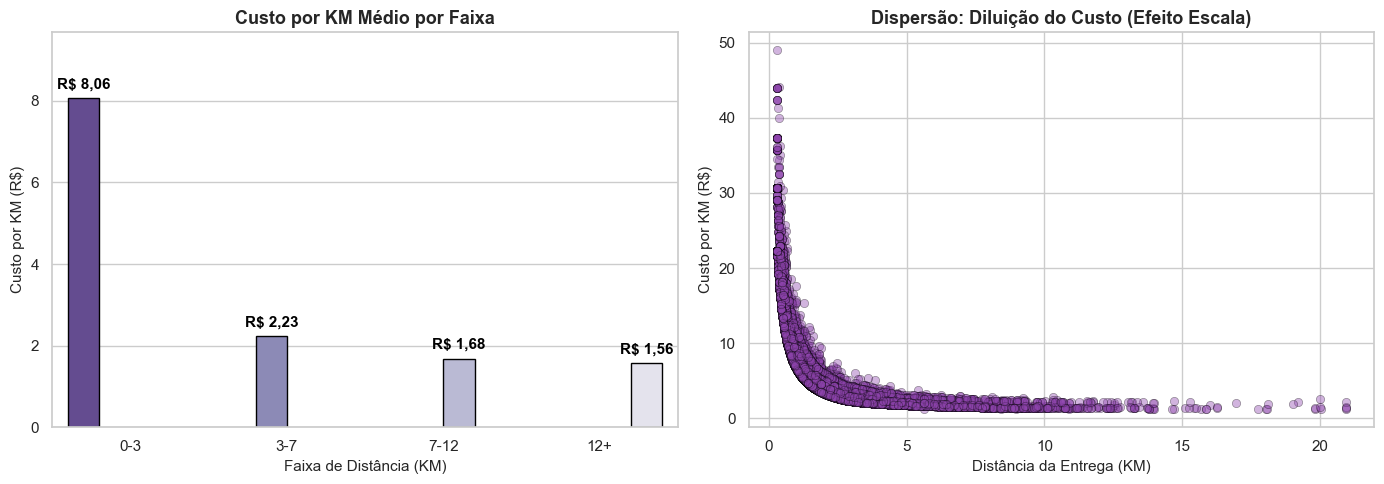

In [69]:
# --- CUSTO POR KM x DISTÂNCIA ---

# 1. Tabela Dinâmica: Custo por KM médio por Faixa de KM
custo_km_faixa = df_escopo.groupby('faixa_km', observed=False).agg(
    Volume=('id_pedido', 'count'),
    Custo_Operacional_Medio=('custo_operacional', 'mean'),
    Custo_Por_KM_Medio=('custo_por_km', 'mean')
).reset_index()

# Formatando a tabela
tabela_custo_km_fmt = custo_km_faixa.copy()
tabela_custo_km_fmt['Custo_Operacional_Medio'] = 'R$ ' + tabela_custo_km_fmt['Custo_Operacional_Medio'].round(2).astype(str).str.replace('.', ',')
tabela_custo_km_fmt['Custo_Por_KM_Medio'] = 'R$ ' + tabela_custo_km_fmt['Custo_Por_KM_Medio'].round(2).astype(str).str.replace('.', ',')

print("--- ANÁLISE DE CUSTO POR KM POR FAIXA DE DISTÂNCIA ---")
display(tabela_custo_km_fmt.style.hide(axis="index"))


# 2. Visualização Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras por Faixa
grafico_barras = sns.barplot(
    data=custo_km_faixa,
    x='faixa_km',
    y='Custo_Por_KM_Medio',
    hue='faixa_km',
    legend=False,
    palette='Purples_r',
    edgecolor='black',
    ax=axes[0]
)
for p in grafico_barras.patches:
    valor = p.get_height()
    grafico_barras.annotate(f"R$ {valor:.2f}".replace('.', ','), 
                   (p.get_x() + p.get_width() / 2., valor), 
                   ha='center', va='bottom', 
                   fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
axes[0].set_title('Custo por KM Médio por Faixa', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Faixa de Distância (KM)', fontsize=11)
axes[0].set_ylabel('Custo por KM (R$)', fontsize=11)
axes[0].set_ylim(0, custo_km_faixa['Custo_Por_KM_Medio'].max() * 1.2)

# Gráfico 2: Dispersão
sns.scatterplot(
    data=df_escopo[df_escopo['km'] < 25], # Filtrando outliers de distância absurdos para focar na concentração da operação
    x='km',
    y='custo_por_km',
    alpha=0.4,
    color='#8E44AD',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Dispersão: Diluição do Custo (Efeito Escala)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Distância da Entrega (KM)', fontsize=11)
axes[1].set_ylabel('Custo por KM (R$)', fontsize=11)

plt.tight_layout()
plt.show()

#### Conclusão da H6: Custo por KM × Distância
A hipótese de diluição do custo por KM é **validada**:
- Entregas de curta distância (0-3 km) possuem o **maior custo por KM**, pois o custo fixo
  da operação (aceite, coleta, espera) é rateado por poucos quilômetros.
- À medida que a distância aumenta, o custo por KM **diminui** pelo efeito de escala.
- O gráfico de dispersão confirma a **curva hiperbólica decrescente** típica de diluição de
  custos fixos.

**Relação H5 x H6**: Embora o custo/km diminua com a distância (H6), a margem total
piora (H5). Isso ocorre porque o custo operacional **absoluto** cresce mais rápido que a
receita nas rotas longas.

### HIPÓTESE 7: Entregas noturnas possuem margem unitária inferior às diurnas

--- ANÁLISE DE MARGEM E CUSTOS POR TURNO ---


turno,Volume,Custo_Medio,Receita_Media,Margem_Unitaria_Media
Manhã,3781,"R$ 8,11","R$ 9,74","R$ 0,21"
Tarde,5752,"R$ 8,51","R$ 10,14","R$ 0,2"
Noite,3782,"R$ 8,58","R$ 10,24","R$ 0,2"


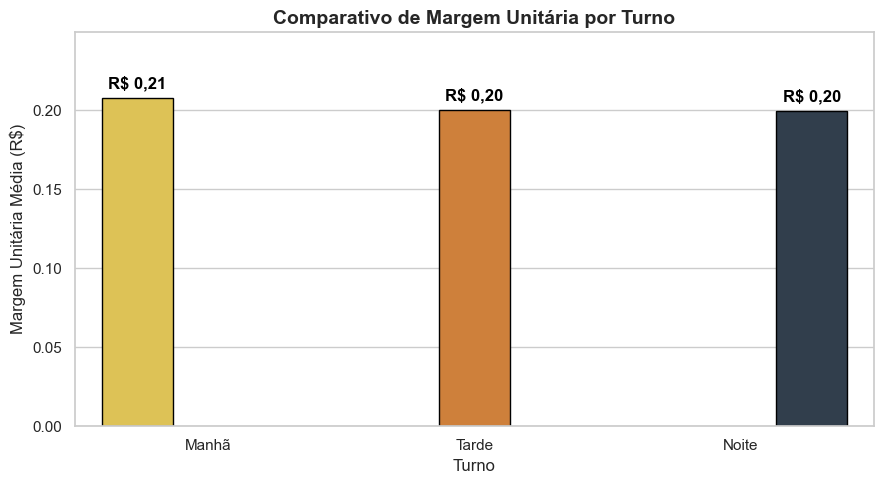

In [70]:
# --- MARGEM UNITÁRIA POR TURNO ---

# 1. Colocando em ordem
turnos_ordem = ['Manhã', 'Tarde', 'Noite']
df_escopo['turno'] = pd.Categorical(df_escopo['turno'], categories=turnos_ordem, ordered=True)

# 2. Tabela Dinâmica: Custos e Margem Média por Turno
margem_turno = df_escopo.groupby('turno', observed=False).agg(
    Volume=('id_pedido', 'count'),
    Custo_Medio=('custo_operacional', 'mean'),
    Receita_Media=('valor_pago_empresa', 'mean'),
    Margem_Unitaria_Media=('margem_unitaria', 'mean')
).reset_index()

tabela_margem_turno_fmt = margem_turno.copy()
tabela_margem_turno_fmt['Custo_Medio'] = 'R$ ' + tabela_margem_turno_fmt['Custo_Medio'].round(2).astype(str).str.replace('.', ',')
tabela_margem_turno_fmt['Receita_Media'] = 'R$ ' + tabela_margem_turno_fmt['Receita_Media'].round(2).astype(str).str.replace('.', ',')
tabela_margem_turno_fmt['Margem_Unitaria_Media'] = 'R$ ' + tabela_margem_turno_fmt['Margem_Unitaria_Media'].round(2).astype(str).str.replace('.', ',')

print("--- ANÁLISE DE MARGEM E CUSTOS POR TURNO ---")
display(tabela_margem_turno_fmt.style.hide(axis="index"))

# 3.Comparativo de Margem por Turno
plt.figure(figsize=(9, 5))

grafico_turno = sns.barplot(
    data=margem_turno,
    x='turno',
    y='Margem_Unitaria_Media',
    hue='turno',
    legend=False,
    palette=['#F4D03F', '#E67E22', '#2C3E50'], # Amarelo (Manhã), Laranja (Tarde), Azul Escuro (Noite)
    edgecolor='black'
)

# Adicionando os rótulos de dados
for p in grafico_turno.patches:
    valor = p.get_height()
    grafico_turno.annotate(f"R$ {valor:.2f}".replace('.', ','), 
                   (p.get_x() + p.get_width() / 2., valor), 
                   ha='center', va='bottom', 
                   fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Comparativo de Margem Unitária por Turno', fontsize=14, fontweight='bold')
plt.xlabel('Turno', fontsize=12)
plt.ylabel('Margem Unitária Média (R$)', fontsize=12)
plt.ylim(0, margem_turno['Margem_Unitaria_Media'].max() * 1.2) 

plt.tight_layout()
plt.show()

#### Conclusão da H7: Turno × Margem
A hipótese é rejeitada pela diferença insignificante entre os turnos analisados.

### HIPÓTESE 8: Pedidos com atraso  possuem custo operacional mais elevado

--- ANÁLISE DE CUSTO OPERACIONAL POR STATUS DE ENTREGA ---


status_otd,Volume,Atraso_Medio_Min,Custo_Operacional_Medio
Atrasado,1592,"-6,03","R$ 9,8"
No Prazo (OTD),11723,"-43,14","R$ 8,23"


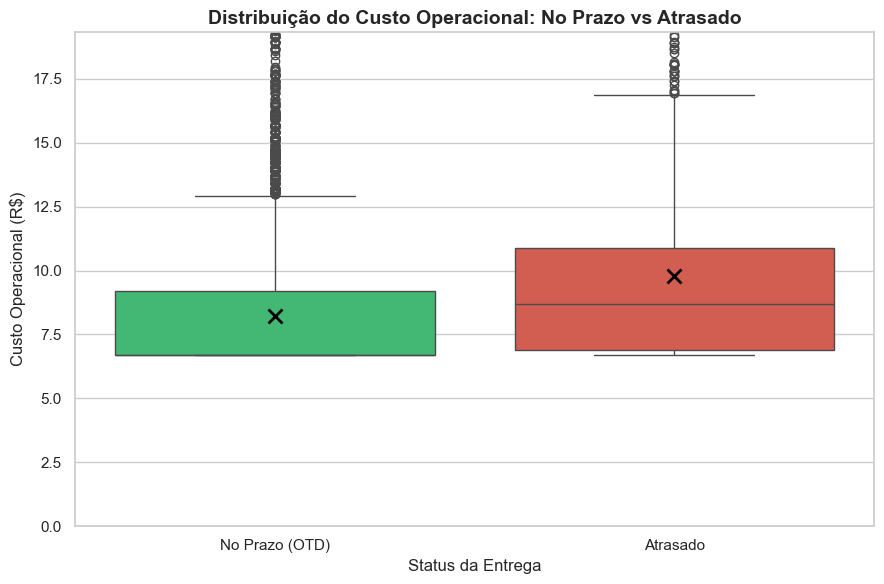

In [71]:
# --- CUSTO OPERACIONAL VS ATRASO ---

df_escopo['status_otd'] = np.where(df_escopo['otd_flag'] == 1, 'No Prazo (OTD)', 'Atrasado')

# Custo Médio por Status de Entrega
custo_atraso = df_escopo.groupby('status_otd').agg(
    Volume=('id_pedido', 'count'),
    Atraso_Medio_Min=('atraso_min', 'mean'),
    Custo_Operacional_Medio=('custo_operacional', 'mean')
).reset_index()

tabela_custo_atraso_fmt = custo_atraso.copy()
tabela_custo_atraso_fmt['Atraso_Medio_Min'] = tabela_custo_atraso_fmt['Atraso_Medio_Min'].round(2).astype(str).str.replace('.', ',')
tabela_custo_atraso_fmt['Custo_Operacional_Medio'] = 'R$ ' + tabela_custo_atraso_fmt['Custo_Operacional_Medio'].round(2).astype(str).str.replace('.', ',')

print("--- ANÁLISE DE CUSTO OPERACIONAL POR STATUS DE ENTREGA ---")
display(tabela_custo_atraso_fmt.style.hide(axis="index"))

# Boxplot de Custo vs Status
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_escopo,
    x='status_otd',
    y='custo_operacional',
    hue='status_otd',
    legend=False,
    palette={'No Prazo (OTD)': '#2ECC71', 'Atrasado': '#E74C3C'}, # Verde para No Prazo, Vermelho para Atrasado
    showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 10, "markeredgewidth": 2}
)

plt.title('Distribuição do Custo Operacional: No Prazo vs Atrasado', fontsize=14, fontweight='bold')
plt.xlabel('Status da Entrega', fontsize=12)
plt.ylabel('Custo Operacional (R$)', fontsize=12)

# Cortando outliers extremamente atípicos)
limite_superior = df_escopo['custo_operacional'].quantile(0.98) * 1.2
plt.ylim(0, limite_superior)

plt.tight_layout()
plt.show()

#### Conclusão da H8: Atraso × Custo Operacional

A análise confirma que pedidos **atrasados** possuem um custo operacional médio **significativamente superior** aos pedidos entregues no prazo:
- Entregas atrasadas demandam mais tempo de deslocamento, espera e operação, elevando o custo.
- O boxplot evidencia que a distribuição de custos dos atrasados é mais **dispersa e deslocada para cima**.

**H8 é validada**: o atraso não apenas impacta a experiência do cliente, mas também **onera financeiramente** a operação, reforçando a urgência de atuar nos fatores geradores de atraso identificados nas hipóteses anteriores (distância, turno, modalidade).